In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt


In [36]:
# Reading the data

data = pd.read_csv('../data/preprocessed/marketing_campaign_preprocessed_CLV.csv')

print(data.info())
data.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 2229 entries, 0 to 2228
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2229 non-null   int64  
 1   Education                 2229 non-null   str    
 2   Income                    2229 non-null   float64
 3   Recency                   2229 non-null   int64  
 4   MntWines                  2229 non-null   int64  
 5   MntFruits                 2229 non-null   int64  
 6   MntMeatProducts           2229 non-null   int64  
 7   MntFishProducts           2229 non-null   int64  
 8   MntSweetProducts          2229 non-null   int64  
 9   MntGoldProds              2229 non-null   int64  
 10  NumDealsPurchases         2229 non-null   int64  
 11  NumWebPurchases           2229 non-null   int64  
 12  NumCatalogPurchases       2229 non-null   int64  
 13  NumStorePurchases         2229 non-null   int64  
 14  NumWebVisitsMonth  

,ID,Education,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Purchases,Total_Accepted_Campaigns,Children_at_home,Living_With,Family_Size
0,5524,Graduate,58138.0,58,635,88,546,172,88,88,...,0,1,69,4928,1617,25,0,0,Alone,1
1,2174,Graduate,46344.0,38,11,1,6,2,1,6,...,0,0,72,4378,27,6,0,2,Alone,3
2,4141,Graduate,71613.0,26,426,49,127,111,21,42,...,0,0,61,4577,776,21,0,0,Partner,2
3,6182,Graduate,26646.0,26,11,4,20,10,3,5,...,0,0,42,4404,53,8,0,1,Partner,3
4,5324,PhD,58293.0,94,173,43,118,46,27,15,...,0,0,45,4426,422,19,0,1,Partner,3


In [37]:
discount_rate = 0.10

data['Tenure_Years'] = data['Customer_Tenure_Days'] / 365
data['AOV'] = data['Total_Spending'] / data['Total_Purchases']
data['Purchase_Frequency'] = data['Total_Purchases'] / data['Tenure_Years']
data['Retention_Rate'] = (1 - (1 / data['Tenure_Years'])).clip(0, 0.99)
data['Annual_Revenue'] = data['AOV'] * data['Purchase_Frequency']

data['CLV_Discounted'] = (
    data['Annual_Revenue'] *
    data['Retention_Rate'] /
    (1 + discount_rate - data['Retention_Rate'])
)

# Drop rows where CLV_Discounted is missing
data_clean = data.dropna(subset=['CLV_Discounted'])

data_clean.head(5)

,ID,Education,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Total_Accepted_Campaigns,Children_at_home,Living_With,Family_Size,Tenure_Years,AOV,Purchase_Frequency,Retention_Rate,Annual_Revenue,CLV_Discounted
0,5524,Graduate,58138.0,58,635,88,546,172,88,88,...,0,0,Alone,1,13.501370,64.680000,1.851664,0.925933,119.765625,637.083874
1,2174,Graduate,46344.0,38,11,1,6,2,1,6,...,0,2,Alone,3,11.994521,4.500000,0.500228,0.916629,2.251028,11.252335
2,4141,Graduate,71613.0,26,426,49,127,111,21,42,...,0,0,Partner,2,12.539726,36.952381,1.674678,0.920253,61.883330,316.825799
3,6182,Graduate,26646.0,26,11,4,20,10,3,5,...,0,1,Partner,3,12.065753,6.625000,0.663034,0.917121,4.392598,22.028435
4,5324,PhD,58293.0,94,173,43,118,46,27,15,...,0,1,Partner,3,12.126027,22.210526,1.566878,0.917533,34.801175,174.996993


In [38]:
data_clean['CLV_Discounted'].mean()

np.float64(245.67878565585093)

In [39]:
features = [
    'Income',
    'Recency',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Age',
    'Customer_Tenure_Days',
    'Total_Accepted_Campaigns',
    'Children_at_home',
    'Family_Size'
]



X = data_clean[features]
y = data_clean['CLV_Discounted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
# Train the XGBRegressor model
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [41]:
# Model Evaluation

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 49.06428918990264
R2 Score: 0.8796085624117371


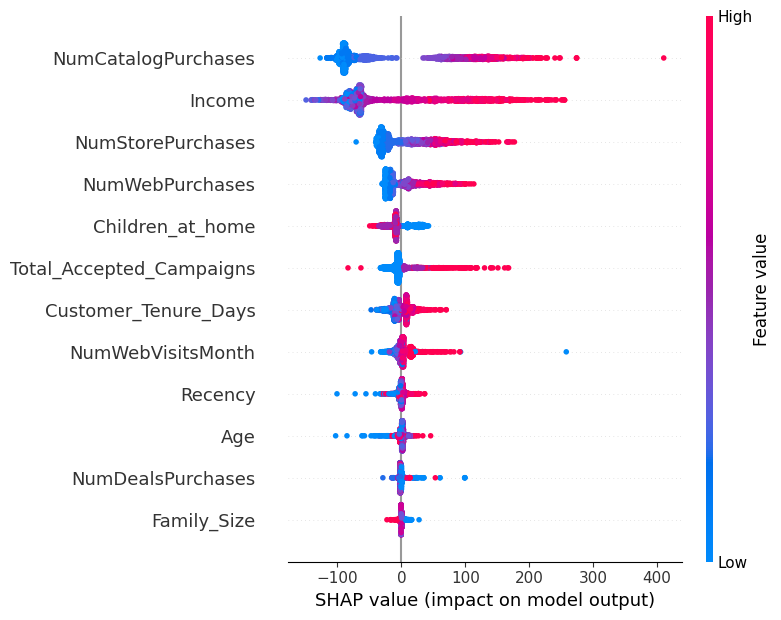

In [42]:
import shap

# Create TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Global Feature Importance (Beeswarm)
shap.summary_plot(shap_values, X)


In [43]:
data_clean['Predicted_CLV'] = model.predict(X)

In [44]:
data_clean['CLV_Tier'] = pd.qcut(data_clean['Predicted_CLV'], q=4, labels=['Low','Mid-Low','Mid-High','High'])

In [45]:
data_clean['CLV_Tier'].value_counts()

CLV_Tier
Low         557
Mid-Low     557
High        557
Mid-High    556
Name: count, dtype: int64

In [46]:
data_clean.head(10)

,ID,Education,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Living_With,Family_Size,Tenure_Years,AOV,Purchase_Frequency,Retention_Rate,Annual_Revenue,CLV_Discounted,Predicted_CLV,CLV_Tier
0,5524,Graduate,58138.0,58,635,88,546,172,88,88,...,Alone,1,13.501370,64.680000,1.851664,0.925933,119.765625,637.083874,570.056792,High
1,2174,Graduate,46344.0,38,11,1,6,2,1,6,...,Alone,3,11.994521,4.500000,0.500228,0.916629,2.251028,11.252335,14.160985,Low
2,4141,Graduate,71613.0,26,426,49,127,111,21,42,...,Partner,2,12.539726,36.952381,1.674678,0.920253,61.883330,316.825799,370.617484,Mid-High
3,6182,Graduate,26646.0,26,11,4,20,10,3,5,...,Partner,3,12.065753,6.625000,0.663034,0.917121,4.392598,22.028435,27.601830,Low
4,5324,PhD,58293.0,94,173,43,118,46,27,15,...,Partner,3,12.126027,22.210526,1.566878,0.917533,34.801175,174.996993,224.935098,Mid-High
5,7446,Postgraduate,62513.0,16,520,42,98,0,42,14,...,Partner,3,12.487671,32.545455,1.761738,0.919921,57.336551,292.899804,300.741768,Mid-High
6,965,Graduate,55635.0,34,235,65,164,50,49,27,...,Alone,2,13.309589,28.095238,1.577810,0.924866,44.328942,234.097245,278.490896,Mid-High
7,6177,PhD,33454.0,32,76,10,56,3,1,23,...,Partner,3,12.827397,16.900000,0.779581,0.922042,13.174925,68.262305,73.318252,Mid-Low
8,4855,PhD,30351.0,19,14,0,24,3,3,2,...,Partner,3,12.747945,7.666667,0.470664,0.921556,3.608425,18.635343,24.965309,Low
9,5899,PhD,5648.0,68,28,0,6,1,1,13,...,Partner,4,11.980822,24.500000,0.166933,0.916533,4.089870,20.431506,9.400397,Low


In [47]:
# reading RFM clustering results file

rfm_results = pd.read_csv('../data/preprocessed/clustering_results.csv')
rfm_results.head(5)

,ID,Education,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Age,Customer_Tenure_Days,Total_Spending,Total_Purchases,Total_Accepted_Campaigns,Children_at_home,Living_With,Family_Size,Cluster,Segment
0,5524,Graduate,58138.0,58,6.455199,4.488636,6.304449,5.153292,4.488636,4.488636,...,69,4928,31.378848,25,0,0,Alone,1,1,Potential Loyals
1,2174,Graduate,46344.0,38,2.484907,0.693147,1.945910,1.098612,0.693147,1.945910,...,72,4378,8.861634,6,0,2,Alone,3,0,New / Occasional
2,4141,Graduate,71613.0,26,6.056784,3.912023,4.852030,4.718499,3.091042,3.761200,...,61,4577,26.391579,21,0,0,Partner,2,2,Loyal Customers
3,6182,Graduate,26646.0,26,2.484907,1.609438,3.044522,2.397895,1.386294,1.791759,...,42,4404,12.714816,8,0,1,Partner,3,0,New / Occasional
4,5324,PhD,58293.0,94,5.159055,3.784190,4.779123,3.850148,3.332205,2.772589,...,45,4426,23.677309,19,0,1,Partner,3,1,Potential Loyals


In [48]:
merged_df = pd.merge(data_clean, rfm_results, on='ID', how='inner')
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2227 entries, 0 to 2226
Data columns (total 69 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   ID                          2227 non-null   int64   
 1   Education_x                 2227 non-null   str     
 2   Income_x                    2227 non-null   float64 
 3   Recency_x                   2227 non-null   int64   
 4   MntWines_x                  2227 non-null   int64   
 5   MntFruits_x                 2227 non-null   int64   
 6   MntMeatProducts_x           2227 non-null   int64   
 7   MntFishProducts_x           2227 non-null   int64   
 8   MntSweetProducts_x          2227 non-null   int64   
 9   MntGoldProds_x              2227 non-null   int64   
 10  NumDealsPurchases_x         2227 non-null   int64   
 11  NumWebPurchases_x           2227 non-null   int64   
 12  NumCatalogPurchases_x       2227 non-null   int64   
 13  NumStorePurchases_x         2

now that we have both RFM segments (Segment) and ML predicted CLV tiers (CLV_Tier) in the same DataFrame, we can do a cross analysis to see how clustering aligns with predicted customer value. This is extremely useful for validating segmentation and designing targeted campaigns.

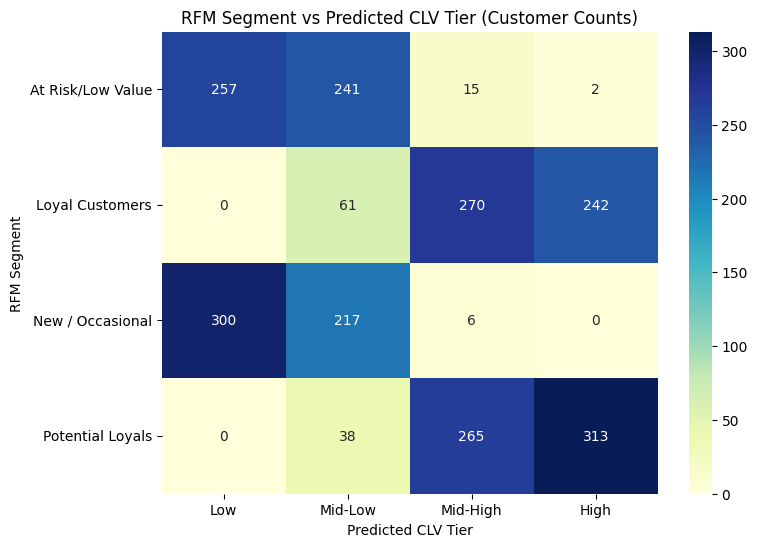

In [49]:

cross_tab_counts = pd.crosstab(
    merged_df['Segment'],
    merged_df['CLV_Tier']
)

plt.figure(figsize=(8,6))
sns.heatmap(cross_tab_counts, annot=True, fmt="d", cmap='YlGnBu')
plt.title("RFM Segment vs Predicted CLV Tier (Customer Counts)")
plt.ylabel("RFM Segment")
plt.xlabel("Predicted CLV Tier")
plt.show()